In [17]:
import pandas as pd
df = pd.read_csv("Files/final_heart_disease.csv")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [18]:
df.head()

,Age,Gender,RestingBP,Cholesterol,MaxHR,HeartDisease
0,68,Male,191.619834,230.673964,179.503788,0
1,58,Male,258.188337,345.179683,144.253064,1
2,44,Male,295.656312,381.851154,136.194128,1
3,72,Male,324.175274,429.427093,116.018220,0
4,37,Female,283.406794,381.635985,138.554728,0


### 3 Find Missing values

In [19]:
missing_values = df.isnull().sum()
print(missing_values)


Age              0
Gender           0
RestingBP       73
Cholesterol     73
MaxHR           73
HeartDisease     0
dtype: int64


### 4 Replace missing values by Mean

In [20]:
df.fillna(df.mean(numeric_only=True), inplace=True)
print(df.isnull().sum())

Age             0
Gender          0
RestingBP       0
Cholesterol     0
MaxHR           0
HeartDisease    0
dtype: int64


### 5  Check for Outliers 

Number of outliers in Cholesterol: 20


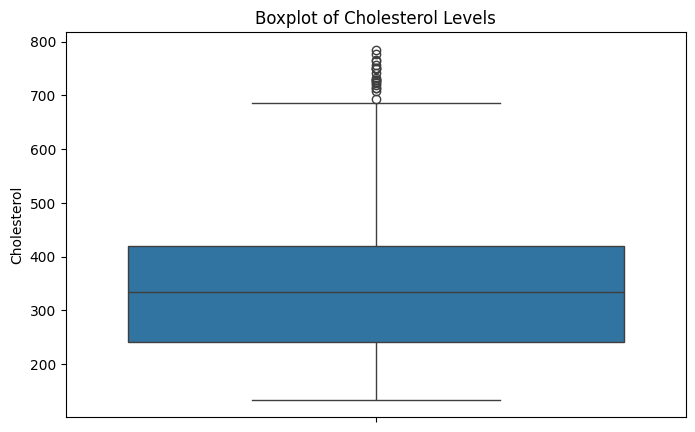

In [21]:
Q1 = df["Cholesterol"].quantile(0.25)
Q3 = df["Cholesterol"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Cholesterol"] < lower_bound) | (df["Cholesterol"] > upper_bound)]
print(f"Number of outliers in Cholesterol: {len(outliers)}")

# Boxplot to visualize outliers
plt.figure(figsize=(8, 5))
sns.boxplot(y=df["Cholesterol"])
plt.title("Boxplot of Cholesterol Levels")
plt.show()

### 6 Drop the outliers

New dataset size after removing outliers: 4480
Number of outliers in Cholesterol: 0


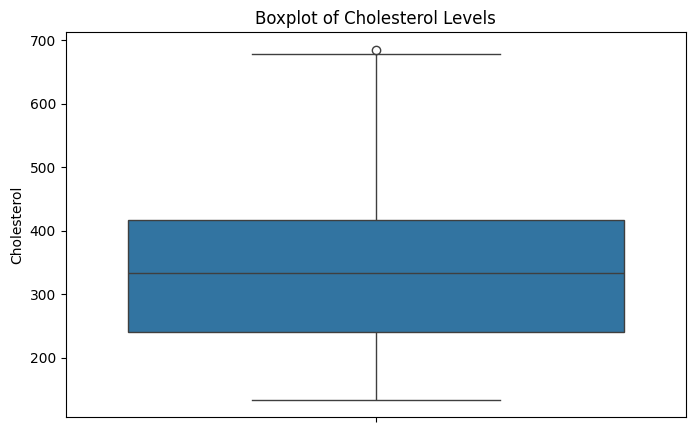

In [22]:

Q1 = df["Cholesterol"].quantile(0.25)
Q3 = df["Cholesterol"].quantile(0.75)
IQR = Q3 - Q1


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


df = df[(df["Cholesterol"] >= lower_bound) & (df["Cholesterol"] <= upper_bound)]


print(f"New dataset size after removing outliers: {df.shape[0]}")
outliers = df[(df["Cholesterol"] < lower_bound) | (df["Cholesterol"] > upper_bound)]
print(f"Number of outliers in Cholesterol: {len(outliers)}")
plt.figure(figsize=(8, 5))
sns.boxplot(y=df["Cholesterol"])
plt.title("Boxplot of Cholesterol Levels")
plt.show()


### 7 Perform Label Encoding

In [23]:
from sklearn.preprocessing import LabelEncoder


encoder = LabelEncoder()


df["Gender"] = encoder.fit_transform(df["Gender"])


print(df["Gender"].unique())

df.sample(10)

[1 0]


,Age,Gender,RestingBP,Cholesterol,MaxHR,HeartDisease
1344,32,1,372.824806,503.657037,100.404793,0
3581,46,1,200.019177,254.280768,171.931754,1
2673,54,1,218.997504,287.239438,159.950776,0
1563,79,0,342.631534,453.656766,120.232913,0
1926,46,1,301.368216,395.671433,132.278980,1
2189,49,1,256.585612,333.309416,149.335552,1
2870,59,1,326.489936,436.709238,115.197438,1
1648,53,0,300.046286,401.963000,120.261112,0
3761,71,0,213.135461,266.165235,164.847705,0
4408,58,0,168.646702,208.122820,191.941103,0


### 8 Cheak Correlation

                   Age    Gender  RestingBP  Cholesterol     MaxHR  \
Age           1.000000  0.008588  -0.003641    -0.002038 -0.001139   
Gender        0.008588  1.000000  -0.002032    -0.001110  0.003474   
RestingBP    -0.003641 -0.002032   1.000000     0.998505 -0.984108   
Cholesterol  -0.002038 -0.001110   0.998505     1.000000 -0.987218   
MaxHR        -0.001139  0.003474  -0.984108    -0.987218  1.000000   
HeartDisease  0.023998 -0.000524   0.024330     0.025665 -0.027858   

              HeartDisease  
Age               0.023998  
Gender           -0.000524  
RestingBP         0.024330  
Cholesterol       0.025665  
MaxHR            -0.027858  
HeartDisease      1.000000  


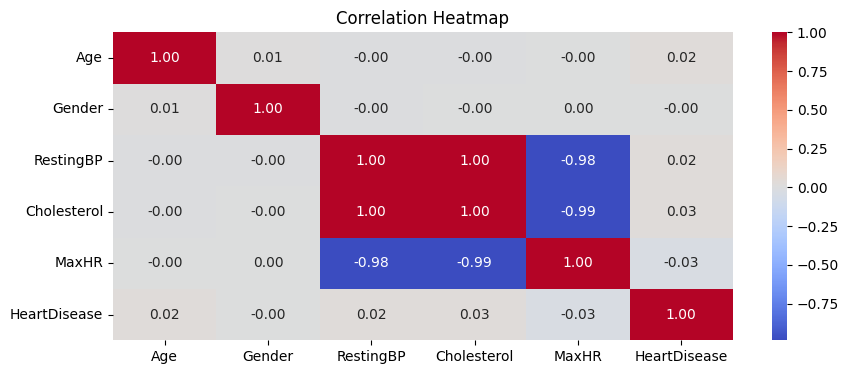

In [24]:

correlation_matrix = df.corr()


print(correlation_matrix)


plt.figure(figsize=(10, 4))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


### 9 Check Outcomes Proportionality

Heart Disease Distribution:
HeartDisease
0    2721
1    1759
Name: count, dtype: int64


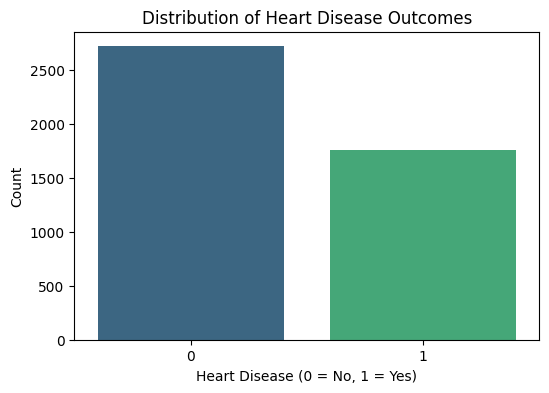

In [25]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)



heart_disease_counts = df["HeartDisease"].value_counts()


print("Heart Disease Distribution:")
print(heart_disease_counts)


plt.figure(figsize=(6, 4))
sns.barplot(x=heart_disease_counts.index, y=heart_disease_counts.values, palette="viridis")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Distribution of Heart Disease Outcomes")
plt.show()


### 10 Separate independent features and Target Variables

In [26]:

X = df[["MaxHR", "RestingBP"]]  
y = df["Cholesterol"]  


print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")


Features shape: (4480, 2)
Target shape: (4480,)


### 11 Apply Normalization or Standardization

In [27]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()


X_scaled = scaler.fit_transform(X)


X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())


      MaxHR  RestingBP
0  0.989818  -0.860644
1 -0.186929   0.039194
2 -0.455954   0.545667
3 -1.129470   0.931171
4 -0.377152   0.380084


### 12 Implement Simple Linear Regression

Mean Squared Error (MSE): 24.38873610359695
R2 Score 0.9975222540529696


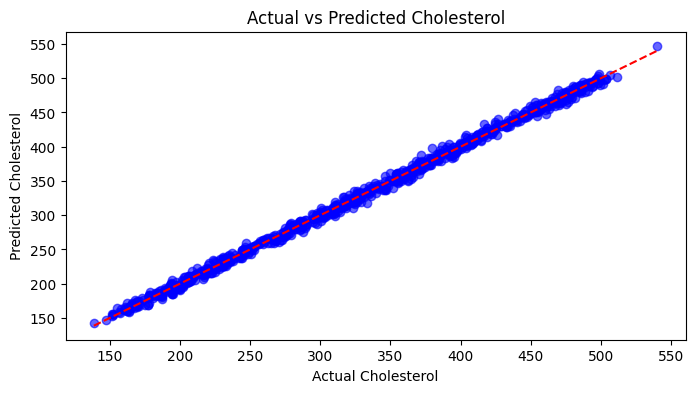

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
X = df[["MaxHR", "RestingBP"]]  
y = df["Cholesterol"] 


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

 
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)
print("R2 Score",r2)

plt.figure(figsize=(8, 4))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label="Predicted vs Actual")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='dashed')
plt.xlabel("Actual Cholesterol")
plt.ylabel("Predicted Cholesterol")
plt.title("Actual vs Predicted Cholesterol")
plt.show()
